<a href="https://colab.research.google.com/github/eniompw/LinearRegressionGD/blob/main/linreg_ames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

slope:     107.1304
intercept: 18569.0259


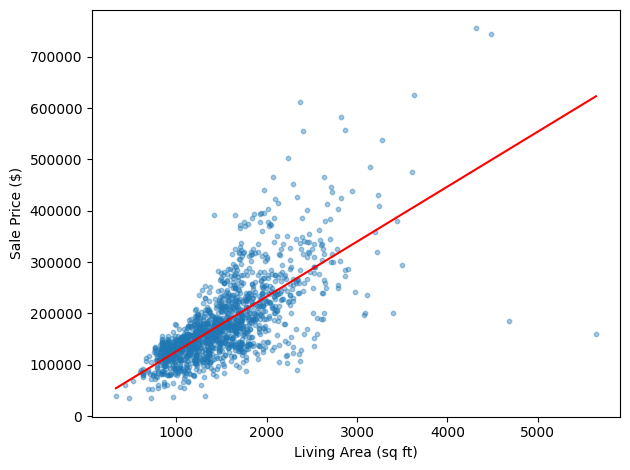

In [2]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

# --- Data ---
ames = fetch_openml(name="house_prices", as_frame=True)
X = ames.data["GrLivArea"].to_numpy(dtype=float)  # Living area (sq ft)
y = ames.target.to_numpy(dtype=float)              # Sale price

# --- Normalise for stable gradient descent ---
X_norm = (X - X.mean()) / X.std()
y_norm = (y - y.mean()) / y.std()

# --- Train: linear regression via gradient descent ---
W, b, lr, n = 0.0, 0.0, 0.1, len(X)

for _ in range(1000):
    y_pred = W * X_norm + b
    error  = y_norm - y_pred
    W -= lr * -(2/n) * np.sum(X_norm * error)
    b -= lr * -(2/n) * np.sum(error)

# --- Denormalise to original scale ---
slope     = W * y.std() / X.std()
intercept = b * y.std() + y.mean() - slope * X.mean()

print(f"slope:     {slope:.4f}")
print(f"intercept: {intercept:.4f}")

# --- Plot ---
x_line = np.array([X.min(), X.max()])
plt.scatter(X, y, alpha=0.4, s=10)
plt.plot(x_line, slope * x_line + intercept, color="red")
plt.xlabel("Living Area (sq ft)"); plt.ylabel("Sale Price ($)")
plt.tight_layout(); plt.show()